In [1]:
from src.data_ingestion import dfs, load_from_gcs, train_df, test_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import shap

from sklearn.preprocessing import StandardScaler # Numerical Var
from scipy.stats import chi2_contingency # Categorical Var
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import recall_score, precision_score


# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split



In [85]:
train_df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [86]:
test_df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,predicted_label,prob_0.0,prob_1.0
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,Highschool,Middle,Former,Employed,0,0,0,0.0,0.559775,0.440225
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,Highschool,Middle,Never,Unemployed,0,0,0,0.0,0.596239,0.403761
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,Highschool,Low,Never,Employed,0,0,0,1.0,0.467121,0.532879
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,...,Graduate,Middle,Former,Employed,0,0,0,1.0,0.485717,0.514283
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,...,Graduate,Low,Current,Unemployed,0,0,0,1.0,0.414053,0.585947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,999995,59,3,185,6.3,7.3,4.4,22.8,0.81,108,...,Highschool,Upper-Middle,Former,Employed,1,0,0,1.0,0.184245,0.815755
299996,999996,50,2,25,5.8,7.8,4.5,29.6,0.93,112,...,Postgraduate,Lower-Middle,Never,Employed,0,0,0,0.0,0.519927,0.480073
299997,999997,63,1,252,5.2,7.5,8.5,25.1,0.77,129,...,Highschool,Middle,Never,Employed,0,0,0,1.0,0.414447,0.585553
299998,999998,48,3,72,4.9,6.9,1.8,27.7,0.89,121,...,Highschool,Low,Current,Retired,0,1,0,0.0,0.529730,0.470270


In [87]:
print("In train but not in test:", set(train_df.columns) - set(test_df.columns))
print("In test but not in train:", set(test_df.columns) - set(train_df.columns))

In train but not in test: {'diagnosed_diabetes'}
In test but not in train: {'prob_1.0', 'prob_0.0', 'predicted_label'}


In [88]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)

In [89]:
combined_df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes', 'predicted_label',
       'prob_0.0', 'prob_1.0'],
      dtype='str')

In [90]:
numeric_t_cols = train_df.select_dtypes(include='number').columns
cat_cols = train_df.select_dtypes(exclude='number').columns
target_var = 'diagnosed_diabetes'
numeric_cols = numeric_t_cols.drop(target_var)

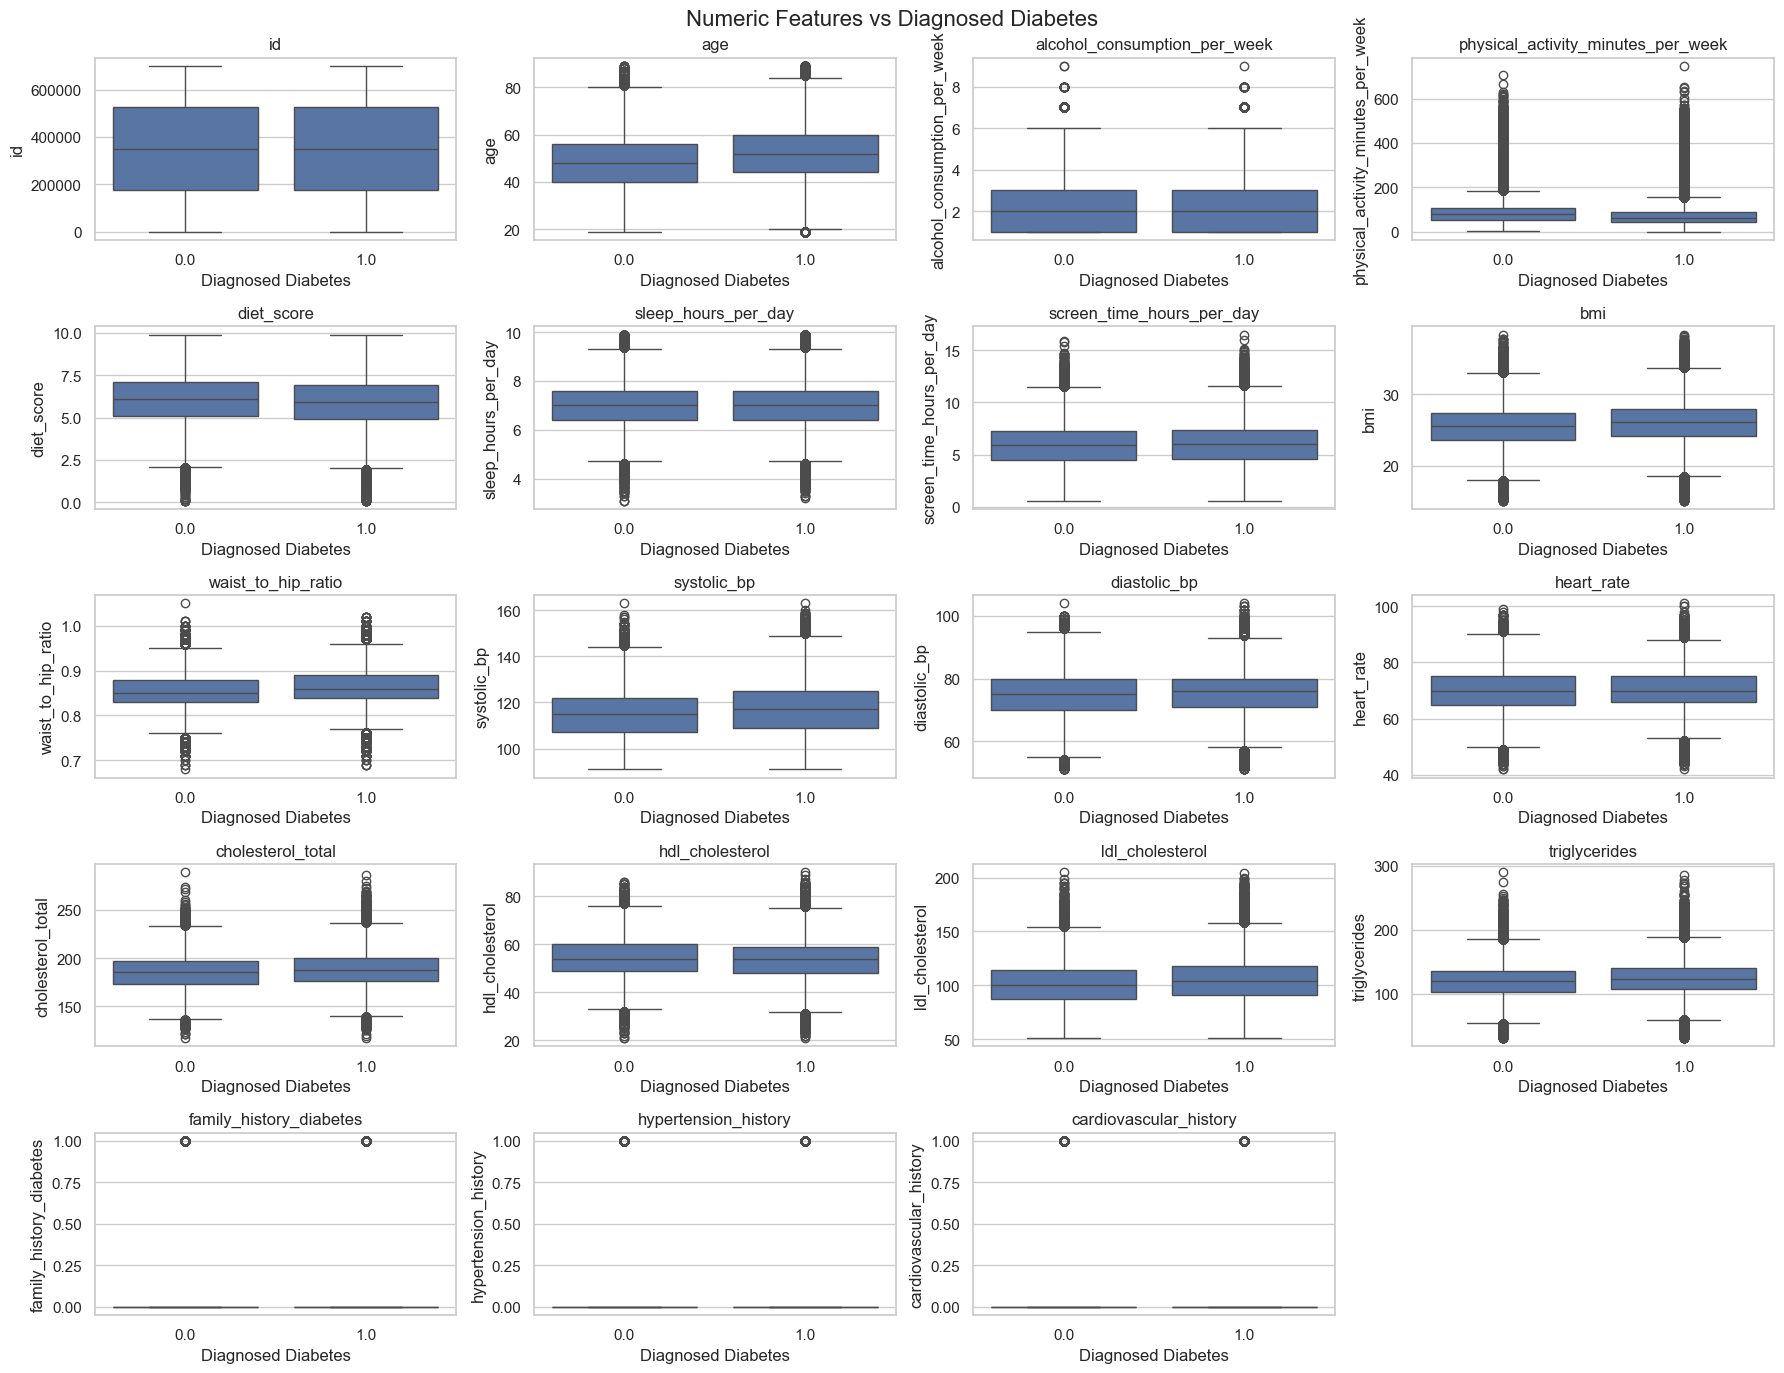

In [91]:
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=train_df[target_var],
        y=train_df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Diagnosed Diabetes")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Features vs Diagnosed Diabetes", fontsize=16)
plt.tight_layout()
plt.show()


In [92]:
cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

for col in cols:
    display(train_df[col].value_counts(normalize=True).round(2).head(10))

family_history_diabetes
0    0.85
1    0.15
Name: proportion, dtype: float64

hypertension_history
0    0.82
1    0.18
Name: proportion, dtype: float64

cardiovascular_history
0    0.97
1    0.03
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Diabetes Based on Family History')

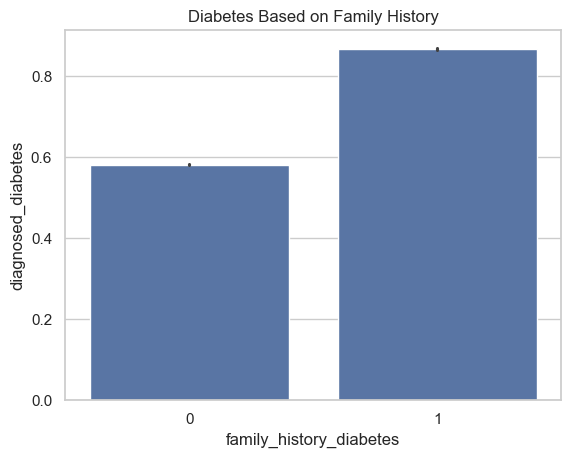

In [93]:
sns.barplot(
    x=train_df['family_history_diabetes'],
    y=train_df[target_var]
)
plt.title("Diabetes Based on Family History")

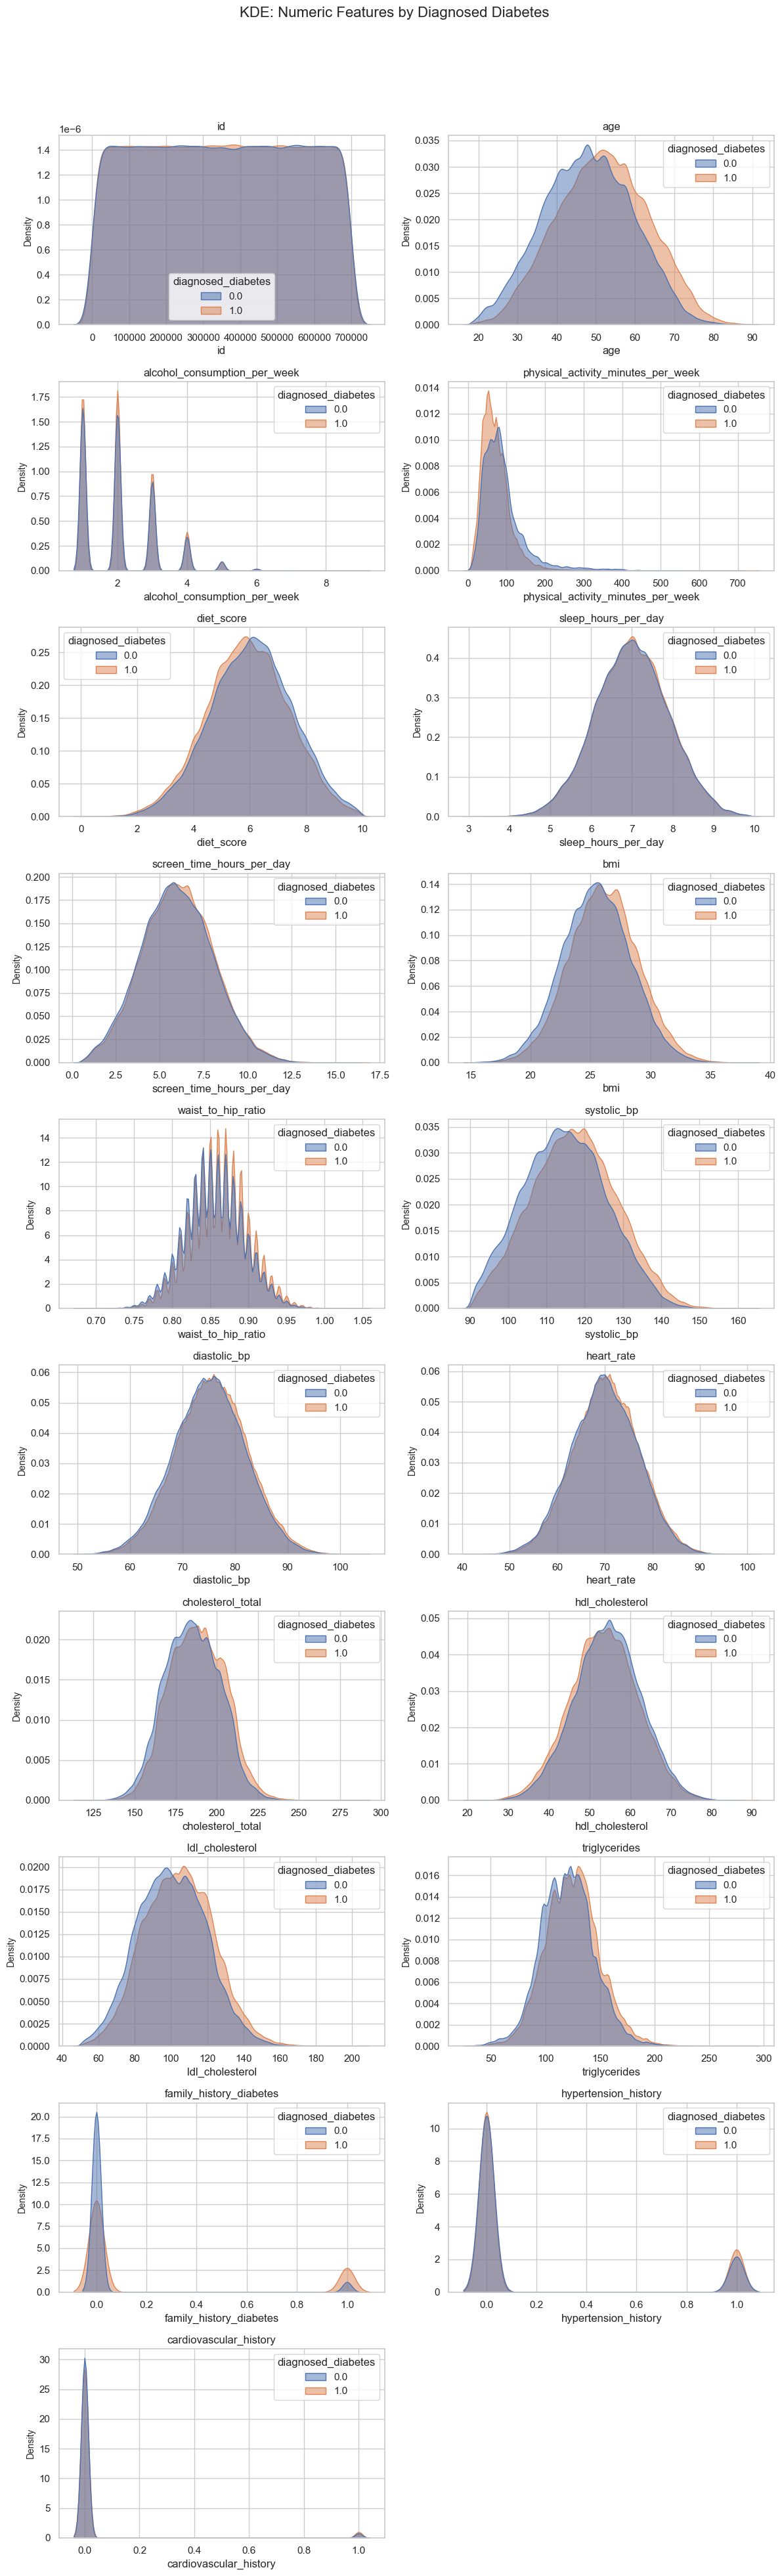

In [ ]:
n_cols = 2
n_rows = (len(numeric_cols) + 1) // n_cols  # calculate rows dynamically
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=train_df,
        x=col,
        hue=target_var,
        common_norm=False,
        fill=True,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Density", fontsize=10)
    axes[i].tick_params(axis='x', rotation=0)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("KDE: Numeric Features by Diagnosed Diabetes", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()


In [ ]:
# Standardizing to Compare Features 
def plot_scaled_kde(df, numeric_cols, target_var, exclude_cols=["id"]):

    numeric_cols_filtered = [
        col for col in numeric_cols
        if col not in exclude_cols and col != target_var
    ]

    scaler = StandardScaler()

    scaled_values = scaler.fit_transform(df[numeric_cols_filtered])
    scaled_df = pd.DataFrame(
        scaled_values,
        columns=numeric_cols_filtered,
        index=df.index
    )

    scaled_df[target_var] = df[target_var]

    n_cols = 2
    n_rows = (len(numeric_cols_filtered) + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols_filtered):
        sns.kdeplot(
            data=scaled_df,
            x=col,
            hue=target_var,
            common_norm=False,
            fill=True,
            alpha=0.4,
            ax=axes[i]
        )
        axes[i].set_title(f"{col} (standardized)")
        axes[i].set_ylabel("Density")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("KDE of Standardized Numeric Features by Target", fontsize=16)
    plt.tight_layout()
    plt.show()

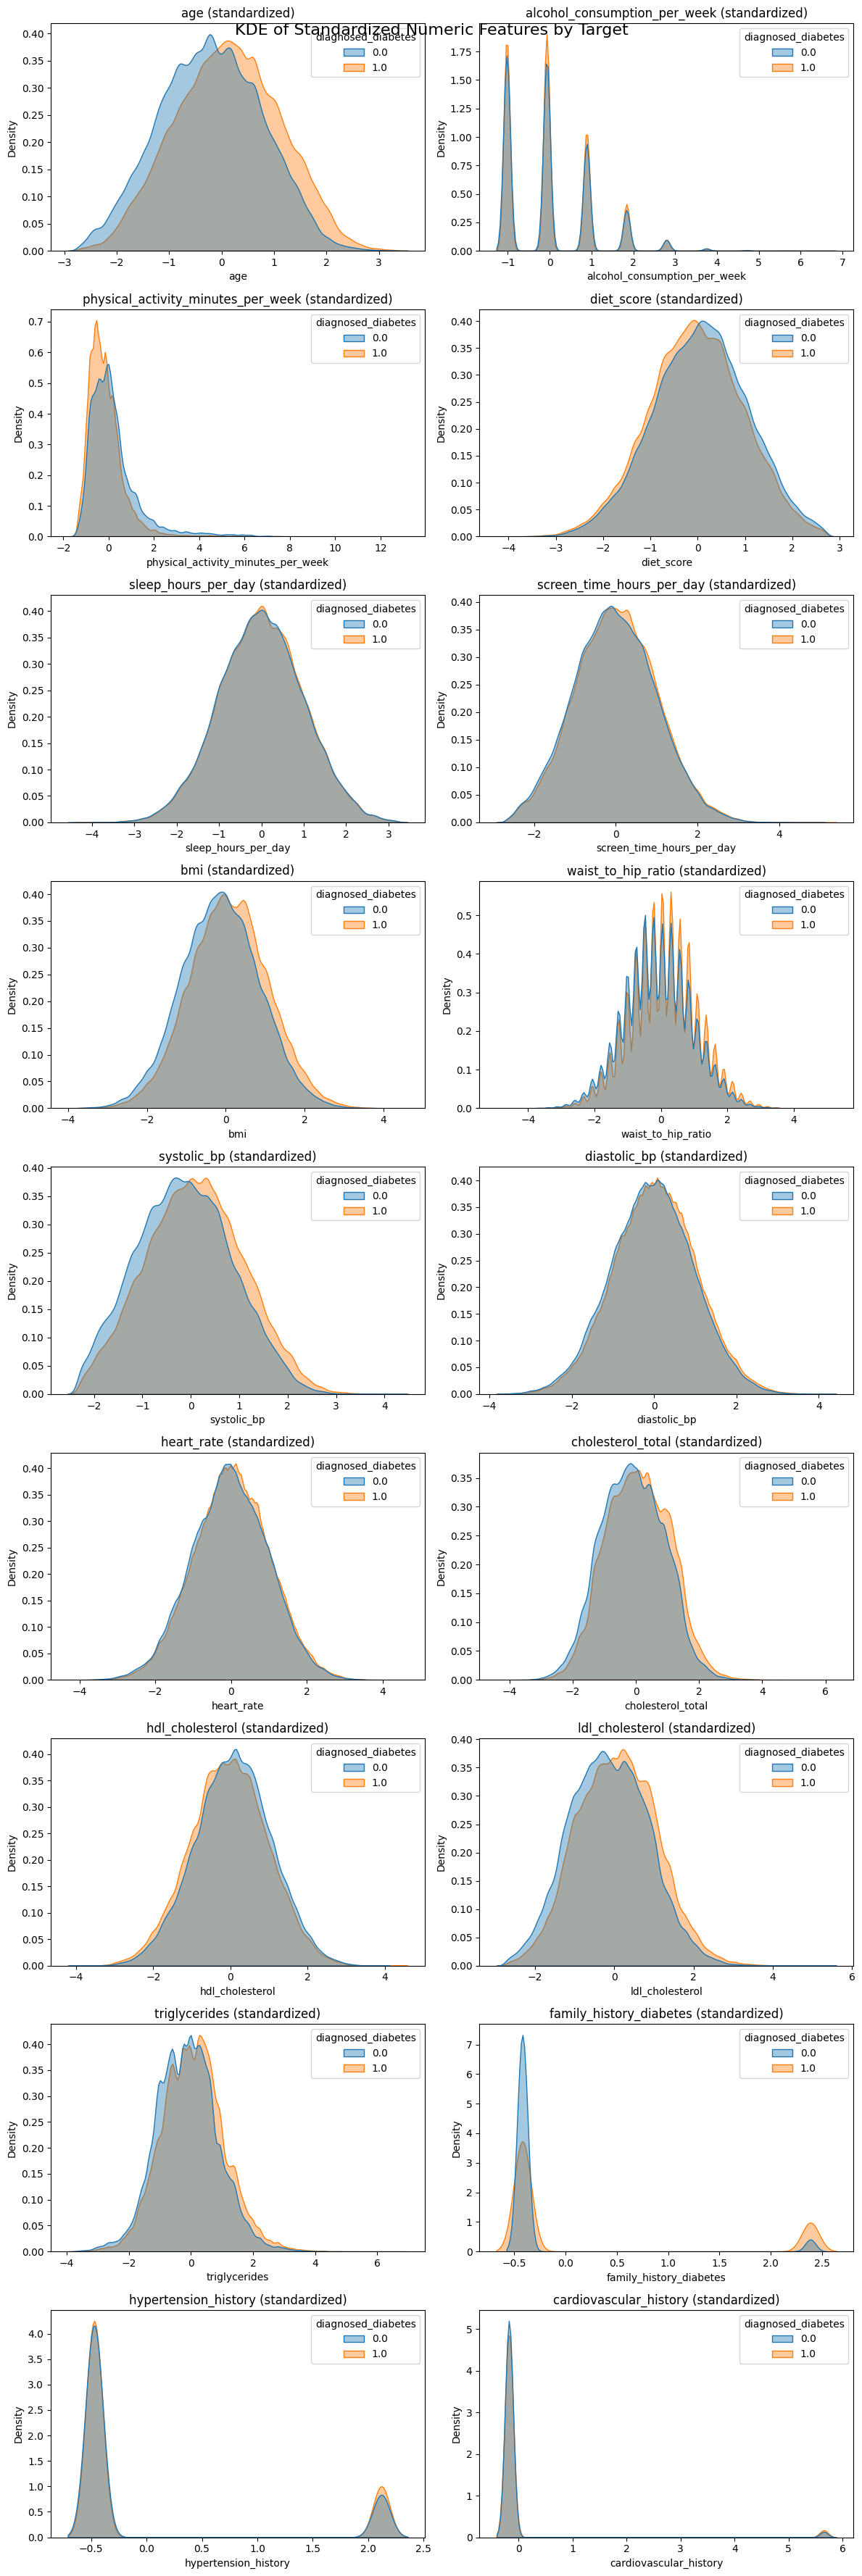

In [ ]:
numeric_t_cols = train_df.select_dtypes(include='number').columns
target_var = 'diagnosed_diabetes'

plot_scaled_kde(train_df, numeric_t_cols, target_var)

**Core predictors**

- BMI
- Waist-to-hip ratio
- Triglycerides
- LDL cholesterol
- Total cholesterol
- Age
- Family history of diabetes

**Secondary / conditional**

- Systolic BP
- HDL cholesterol
- Hypertension history 

In [101]:
train_df.columns 

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='str')

In [102]:
cat_cols = train_df.select_dtypes(exclude='number').columns

C:\Users\pasup\AppData\Local\Temp\ipykernel_29472\1859627088.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, palette=PALETTE[:len(rates)], ax=ax)
C:\Users\pasup\AppData\Local\Temp\ipykernel_29472\1859627088.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rates.index, rotation=35, ha='right', fontsize=9)
C:\Users\pasup\AppData\Local\Temp\ipykernel_29472\1859627088.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, palette=PALETTE[:len(rates)], ax=ax)
C:\Users\pasup\AppData\Local\Temp\ipykernel_29472\1859627088.py:39:

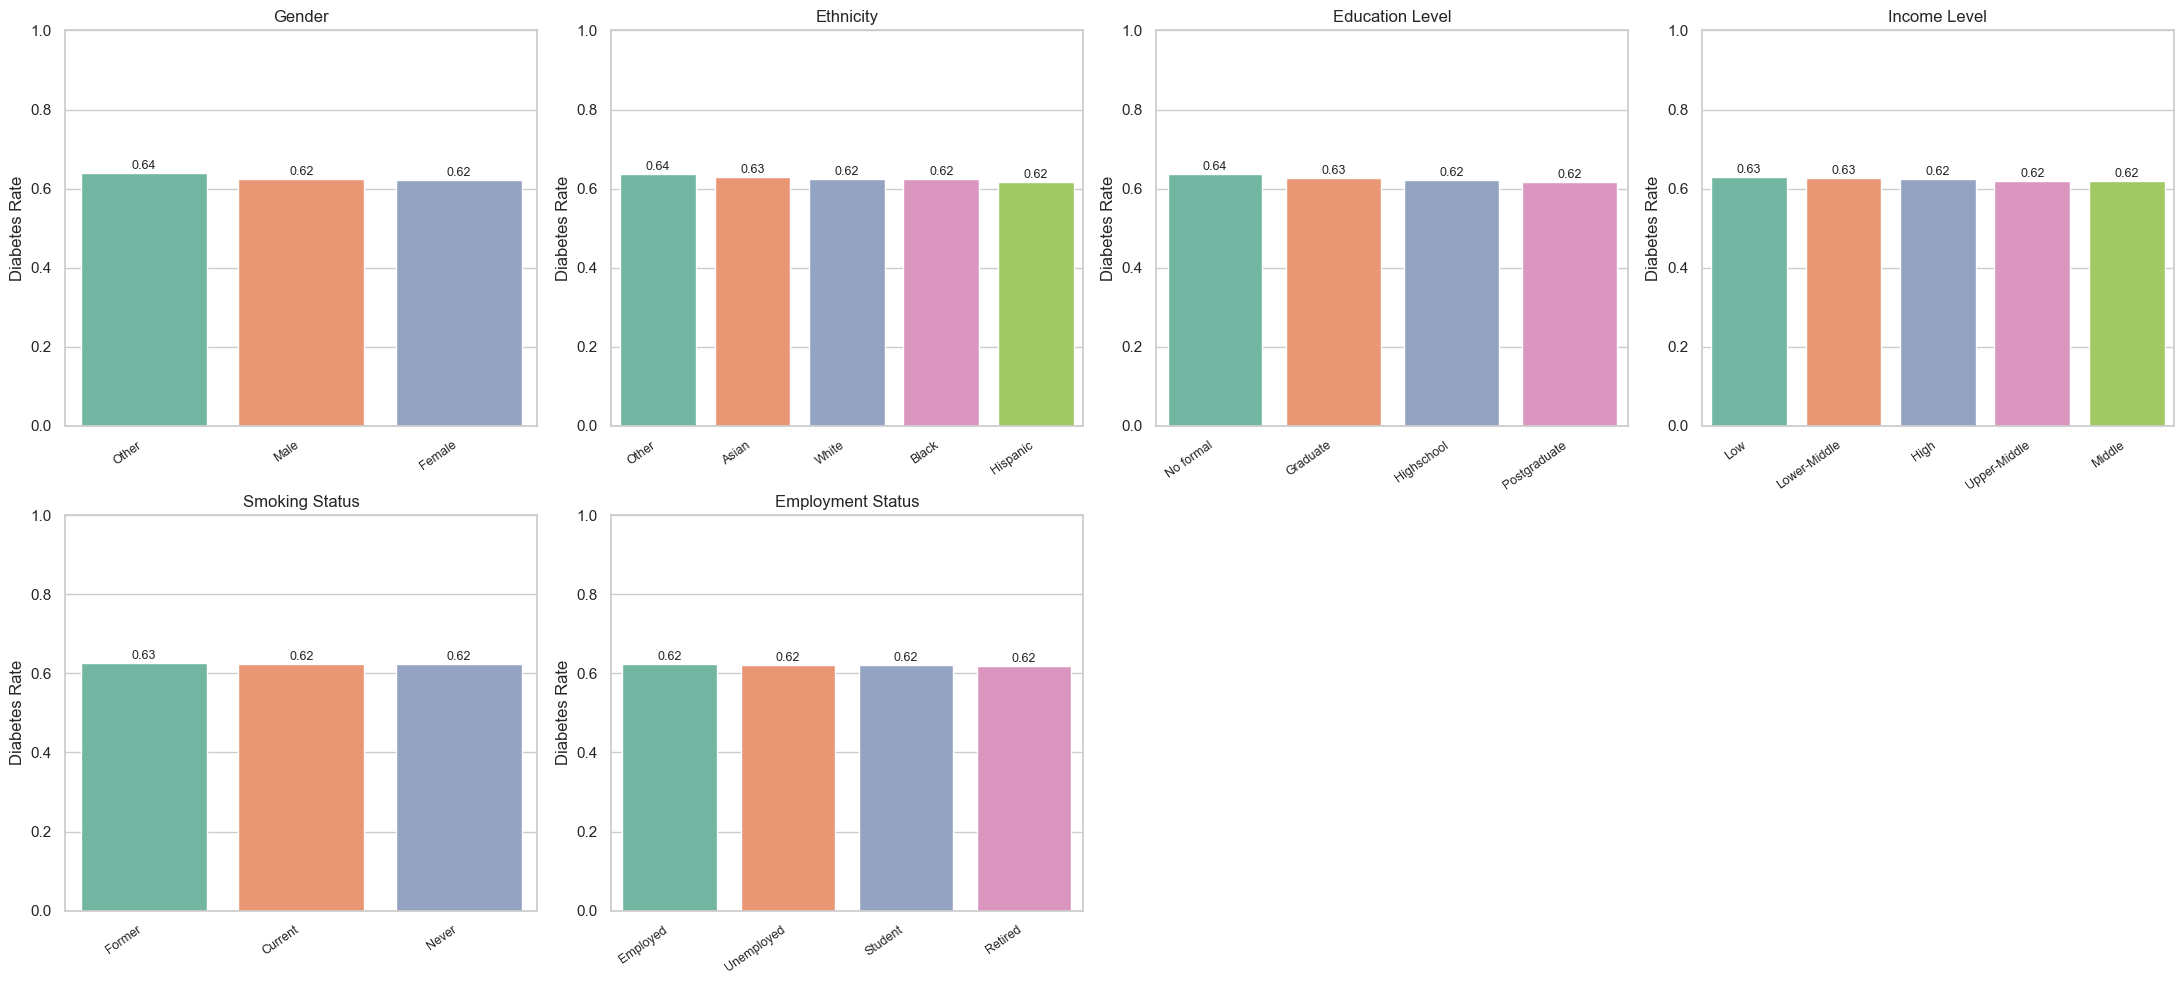

In [ ]:
# Settings
# sns.set(style='whitegrid')  # light background
PALETTE = sns.color_palette('Set2')  # nice pastel palette

def plot_categorical_rates(df, cat_cols, target, n_cols=4, figsize=(22, 10)):
    """
    Plot categorical features vs target rate.

    Parameters:
    - df: DataFrame
    - cat_cols: list of categorical column names
    - target: target column name
    - n_cols: number of columns in subplot grid
    - figsize: figure size
    """
    n_rows = (len(cat_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # make it easy to index
    
    for i, col in enumerate(cat_cols):
        rates = df.groupby(col)[target].mean().sort_values(ascending=False)
        counts = df[col].value_counts().reindex(rates.index)  # same order as rates
        
        ax = axes[i]
        sns.barplot(x=rates.index, y=rates.values, palette=PALETTE[:len(rates)], ax=ax)
        
        # Annotate diabetes rate on top
        for j, val in enumerate(rates.values):
            ax.text(j, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
        
        ax.set_title(col.replace('_', ' ').title(), fontsize=12)
        ax.set_ylabel('Diabetes Rate')
        ax.set_xlabel('')
        ax.set_ylim(0, 1)
        ax.set_xticklabels(rates.index, rotation=35, ha='right', fontsize=9)
    
    # Hide empty subplots
    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Example usage
cat_cols = train_df.select_dtypes(exclude='number').columns  #  categorical columns
target_var = 'diagnosed_diabetes'
plot_categorical_rates(train_df, cat_cols, target_var)  # replace 'diabetes' with your target

In [105]:
type(cat_cols)

pandas.Index

In [106]:
cat_cols = train_df.select_dtypes(exclude='number').columns
total_cols = ['age','bmi','waist_to_hip_ratio', 'triglycerides','hdl_cholesterol','ldl_cholesterol',
              'cholesterol_total','systolic_bp', 'family_history_diabetes', 'hypertension_history', 'diagnosed_diabetes'] + list(cat_cols)

train_subset = train_df[total_cols]

In [ ]:
train_subset.columns

Index(['age', 'bmi', 'waist_to_hip_ratio', 'triglycerides', 'hdl_cholesterol',
       'ldl_cholesterol', 'cholesterol_total', 'systolic_bp',
       'family_history_diabetes', 'hypertension_history', 'gender',
       'ethnicity', 'education_level', 'income_level', 'smoking_status',
       'employment_status'],
      dtype='str')


Top correlations with diagnosed_diabetes:
family_history_diabetes    0.211064
age                        0.161162
systolic_bp                0.107132
bmi                        0.105580
ldl_cholesterol            0.102771
triglycerides              0.090635
cholesterol_total          0.088112
waist_to_hip_ratio         0.081050
hdl_cholesterol            0.053231
hypertension_history       0.029979


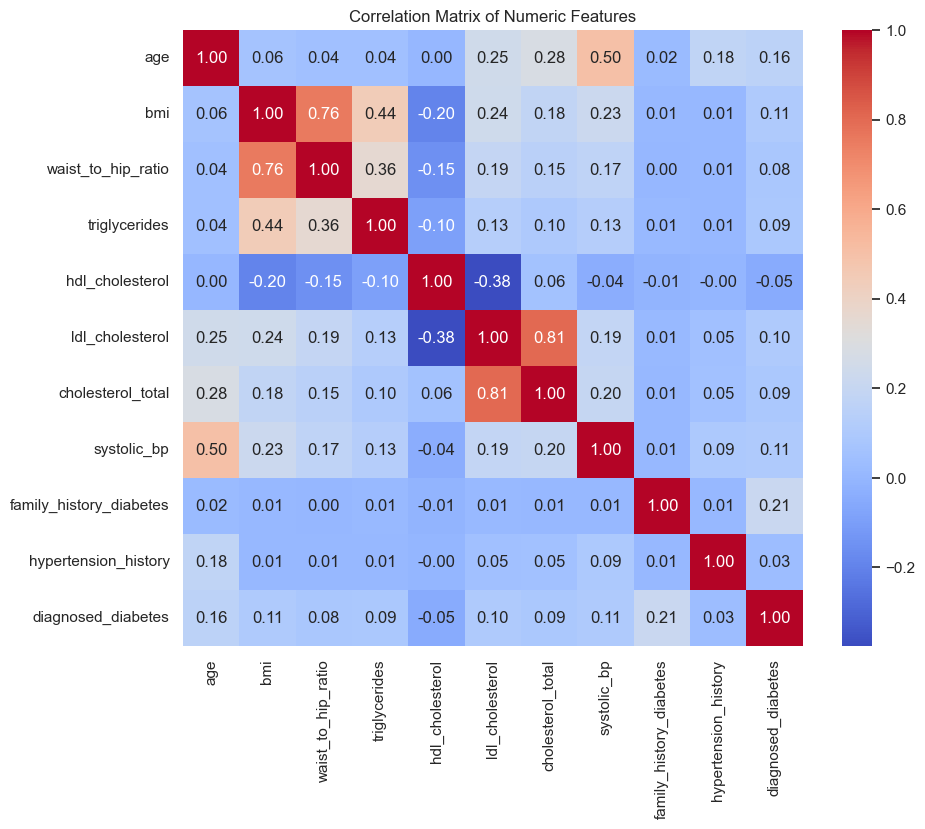

In [107]:
def correlation_matrix(df, target_var= 'diagnosed_diabetes'):
    correlation_matrix = df.corr(numeric_only=True)
    #print("Full Correlation Matrix:")
    #print(correlation_matrix)
    plt.figure(figsize=(10,8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix of Numeric Features")
    print('\nTop correlations with diagnosed_diabetes:')
    print(correlation_matrix[target_var].drop(target_var).abs().sort_values(ascending=False).head(12).to_string())
    return plt.show()

correlation_matrix(train_subset, 'diagnosed_diabetes')

**Strong correlations between predictors**

- bmi & waist_to_hip_ratio - 0.76

- Very high correlation; these features capture similar body composition info.

- ldl_cholesterol & cholesterol_total - 0.81

- Extremely high correlation; total cholesterol includes LDL, so this is expected.

- These two pairs are clear multicollinear relationships.

**Mild correlations worth noting**

- age & systolic_bp - 0.50

- age & cholesterol_total - 0.28

- ldl_cholesterol & cholesterol_total - 0.81

In [ ]:
def cramers_v(x, y):
    """Compute Cramér's V for categorical-categorical association"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / (min(k-1, r-1)))

# Get categorical columns
cat_cols = train_subset.select_dtypes(exclude='number').columns.tolist()

# Compute Cramér's V between each categorical feature and the target
cat_assoc = {col: cramers_v(train_subset[col], train_subset[target_var]) for col in cat_cols}

cat_assoc = pd.Series(cat_assoc).sort_values(ascending=False)

print("\nTop associations with diagnosed_diabetes (categorical features):")
print(cat_assoc.head(12))


Top associations with diagnosed_diabetes (categorical features):
ethnicity            0.008194
education_level      0.008074
income_level         0.007863
employment_status    0.005075
gender               0.003365
smoking_status       0.001744
dtype: float64


All the categorical features have extremely low association with diagnosed_diabetes (Cramér’s V < 0.01).
- Even the highest (ethnicity ~ 0.008) is essentially noise for modeling purposes.

In [ ]:
# Features
features = [
    'family_history_diabetes',
    'age',
    'systolic_bp',
    'bmi',
    'ldl_cholesterol',
    'triglycerides',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'hdl_cholesterol',
    'hypertension_history'
]

# Train/Validation split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    train_df[features], train_df['diagnosed_diabetes'],
    test_size=0.2, random_state=42, stratify=train_df['diagnosed_diabetes']
)

# Train logistic regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

# Validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_val_pred = logreg.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

# Predict on test_df (unlabeled)
X_test = test_df[features]
test_preds = logreg.predict(X_test)            # Predicted labels
test_proba = logreg.predict_proba(X_test)      # Probabilities per class

# Save predictions
test_df['predicted_label'] = test_preds
for i, cls in enumerate(logreg.classes_):
    test_df[f'prob_{cls}'] = test_proba[:, i]


test_df_ori = test_df.copy()
test_df = test_df[['id', 'predicted_label']]
test_df.rename(columns = {"predicted_label" : "diabetes_diagnosed"}, inplace = True)

# test_df.to_csv('test_predictions.csv', index=False)
print("Predictions saved. Sample:")
print(test_df.head())

Validation Accuracy: 0.60055

Classification Report:
               precision    recall  f1-score   support

         0.0       0.48      0.70      0.57     52739
         1.0       0.75      0.54      0.63     87261

    accuracy                           0.60    140000
   macro avg       0.61      0.62      0.60    140000
weighted avg       0.65      0.60      0.61    140000


Confusion Matrix:
 [[36934 15805]
 [40118 47143]]
Predictions saved. Sample:
       id  diabetes_diagnosed
0  700000                 0.0
1  700001                 0.0
2  700002                 1.0
3  700003                 1.0
4  700004                 1.0


In [ ]:
# Training performance

y_train_pred = logreg.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.5994142857142857

Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.48      0.70      0.57    210954
         1.0       0.75      0.54      0.63    349046

    accuracy                           0.60    560000
   macro avg       0.61      0.62      0.60    560000
weighted avg       0.65      0.60      0.60    560000


Training Confusion Matrix:
 [[147284  63670]
 [160658 188388]]


The near-identical metrics across training and validation sets indicate that the logistic regression model generalizes consistently and shows no evidence of overfitting. A significant performance gap between training and validation would be expected if overfitting were present, which is not observed here.

In [ ]:
# CM of Valid Data
cm = confusion_matrix(y_val, y_val_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (No Diabetes)", "Actual 1 (Diabetes)"],
    columns=["Predicted 0 (No Diabetes)", "Predicted 1 (Diabetes)"]
)

print(cm_df)

                        Predicted 0 (No Diabetes)  Predicted 1 (Diabetes)
Actual 0 (No Diabetes)                      36934                   15805
Actual 1 (Diabetes)                         40118                   47143


In [ ]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (No Diabetes)", "Actual 1 (Diabetes)"],
    columns=["Predicted 0 (No Diabetes)", "Predicted 1 (Diabetes)"]
)

print(cm_df)

                        Predicted 0 (No Diabetes)  Predicted 1 (Diabetes)
Actual 0 (No Diabetes)                     147284                   63670
Actual 1 (Diabetes)                        160658                  188388


**Recall Analysis and False Negatives (Underfitting, Non - Linear Patterns)**

For the positive class (diagnosed diabetes), the model achieves a recall of 0.54 on the validation set. This means that the model correctly identifies only 54% of individuals who actually have diabetes.

From the validation confusion matrix:

* True Positives (TP): 47,143

* False Negatives (FN): 40,118

This indicates that approximately 46% of diabetic individuals are misclassified as non-diabetic, representing a substantial number of missed cases.

In healthcare applications, recall levels below commonly accepted screening thresholds (often **≥0.70**) are generally considered insufficient, as false negatives carry a higher clinical risk than false positives. Missing a diabetic patient may delay diagnosis and treatment, leading to adverse health outcomes.

In [76]:
test_df = test_df[['id', 'predicted_label']]
test_df.rename(columns = {"predicted_label" : "diabetes_diagnosed"}, inplace = True)

In [78]:
test_df.to_csv('test_predictions.csv', index=False)

In [77]:
test_df

,id,diabetes_diagnosed
0,700000,0.0
1,700001,0.0
2,700002,1.0
3,700003,1.0
4,700004,1.0
...,...,...
299995,999995,1.0
299996,999996,0.0
299997,999997,1.0
299998,999998,0.0


In [80]:
test_df['diabetes_diagnosed'].value_counts(normalize = True)

diabetes_diagnosed
0.0    0.540063
1.0    0.459937
Name: proportion, dtype: float64

In [81]:
print(test_df.info())       # Check non-null counts and column types
print(test_df.head())       # Preview first few rows
print(test_df.describe())   # Only gives stats for numeric, useful if you have lengths

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 2 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  300000 non-null  int64  
 1   diabetes_diagnosed  300000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 4.6 MB
None
       id  diabetes_diagnosed
0  700000                 0.0
1  700001                 0.0
2  700002                 1.0
3  700003                 1.0
4  700004                 1.0
                  id  diabetes_diagnosed
count  300000.000000       300000.000000
mean   849999.500000            0.459937
std     86602.684716            0.498393
min    700000.000000            0.000000
25%    774999.750000            0.000000
50%    849999.500000            0.000000
75%    924999.250000            1.000000
max    999999.000000            1.000000


In [ ]:
# Predict probabilities (NOT labels)
X_test = test_df_ori[features]
# Picking up diabetes column
test_proba = logreg.predict_proba(X_test)[:, 1]

# Create submission file
submission = pd.DataFrame({
    "id": test_df["id"],
    "diabetes_diagnosed": test_proba
})


In [112]:
submission

,id,diabetes_diagnosed
0,700000,0.440225
1,700001,0.403761
2,700002,0.532879
3,700003,0.514283
4,700004,0.585947
...,...,...
299995,999995,0.815755
299996,999996,0.480073
299997,999997,0.585553
299998,999998,0.470270


In [ ]:
# Probabilities of Predicted Test Data
submission.to_csv("test_predictions_pr.csv", index=False)

print("Submission saved. Sample:")
print(submission.head())

Submission saved. Sample:
       id  diabetes_diagnosed
0  700000            0.440225
1  700001            0.403761
2  700002            0.532879
3  700003            0.514283
4  700004            0.585947


**Implications and Next Steps**

- Recall-oriented probability threshold tuning, since in healthcare, the question is usually: “At what probability should we start worrying about diabetes?”

- Introduction of interaction or non-linear features/methods

- Evaluation of more expressive models such as tree-based or ensemble methods

These approaches are particularly important in healthcare applications, where maximizing sensitivity to positive cases is often a priority.

**Understanding Threshold with Base Model**

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05) 

test_proba = logreg.predict_proba(X_test)[:, 1] # P(Positive Class)
 
for t in thresholds: 
    y_pred_t = (test_proba >= t).astype(int) 
    recall = recall_score(y_val, y_pred_t) 
    precision = precision_score(y_val, y_pred_t) 
    print(f"Threshold={t:.2f} | Recall={recall:.3f} | Precision={precision:.3f}")

In [ ]:
# Validation probabilities (NOT test), Threshold tuning MUST be done on validation data, never on test data.

y_val_proba = logreg.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    recall = recall_score(y_val, y_pred_t)
    precision = precision_score(y_val, y_pred_t)
    print(f"Threshold={t:.2f} | Recall={recall:.3f} | Precision={precision:.3f}")

Threshold=0.10 | Recall=1.000 | Precision=0.623
Threshold=0.15 | Recall=1.000 | Precision=0.623
Threshold=0.20 | Recall=1.000 | Precision=0.624
Threshold=0.25 | Recall=0.994 | Precision=0.627
Threshold=0.30 | Recall=0.969 | Precision=0.636
Threshold=0.35 | Recall=0.911 | Precision=0.654
Threshold=0.40 | Recall=0.813 | Precision=0.678
Threshold=0.45 | Recall=0.683 | Precision=0.710
Threshold=0.50 | Recall=0.540 | Precision=0.749
Threshold=0.55 | Recall=0.411 | Precision=0.790
Threshold=0.60 | Recall=0.312 | Precision=0.829
Threshold=0.65 | Recall=0.247 | Precision=0.858
Threshold=0.70 | Recall=0.207 | Precision=0.874
Threshold=0.75 | Recall=0.169 | Precision=0.886
Threshold=0.80 | Recall=0.119 | Precision=0.901
Threshold=0.85 | Recall=0.057 | Precision=0.924


  To answer, **At what probability should we start worrying about diabetes?**

Choose the threshold (e.g. 0.40) to classify,

- If P(diabetes) ≥ 0.40 - classify as diabetic
- If P(diabetes) < 0.40 - classify as non-diabetic

**Feature Engineering**

In [ ]:
# #from codecs import getencoder
# ethnicity * smoking_status
# ethnicity * gender
# gender * smoking_status
# income_level * bmi
# bmi * ethnicity
# employment_status * smoking_status * hypertension_history
# systolic_bp * gender
# family_history_diabetes * ethnicity

In [11]:
num_features = [
    'age',
    'systolic_bp',
    'bmi',
    'ldl_cholesterol',
    'hdl_cholesterol',
    'triglycerides',
    'cholesterol_total',
    'waist_to_hip_ratio'
]
cat_features = [ 
    'family_history_diabetes',
    'hypertension_history',
    'ethnicity',
    'gender',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
]
engineered_flags = [ 
    'is_obese',
    'is_central_obese',
    'high_bp_flag',
    'high_cholesterol_flag'
]
engineered_cat = [
    'ethnicity_smoking',
    'ethnicity_gender',
    'gender_smoking',
    'income_bmi_bucket',
    'bmi_ethnicity_bucket',
    'employment_smoking_hypertension',
    'family_history_ethnicity'
]

In [ ]:
# Feature Engineering
def feature_engineering(df):
    # Ratios
    df['ldl_hdl_ratio'] = df['ldl_cholesterol'] / (df['hdl_cholesterol'] + 1e-6)
    df['trig_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1e-6)
    df['cholesterol_hdl_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1e-6)

    # Interactions
    df['bmi_age_interaction'] = df['bmi'] * df['age']
    df['bmi_waist_ratio'] = df['bmi'] * df['waist_to_hip_ratio']
    df['systolic_bp_ldl_interaction'] = df['systolic_bp'] * df['ldl_cholesterol']

    # Flags
    df['is_obese'] = (df['bmi'] >= 30).astype(int)
    df['is_central_obese'] = (df['waist_to_hip_ratio'] > 0.9).astype(int)
    df['high_bp_flag'] = (df['systolic_bp'] >= 140).astype(int)
    df['high_cholesterol_flag'] = (df['cholesterol_total'] >= 240).astype(int)

    # Categorical Interactions
    df['ethnicity_smoking'] = df['ethnicity'].astype(str) + "_" + df['smoking_status'].astype(str)
    df['ethnicity_gender'] = df['ethnicity'].astype(str) + "_" + df['gender'].astype(str)
    df['gender_smoking'] = df['gender'].astype(str) + "_" + df['smoking_status'].astype(str)
    df['income_bmi_bucket'] = df['income_level'].astype(str) + "_" + pd.cut(df['bmi'], bins=[0,25,30,100]).astype(str)
    df['bmi_ethnicity_bucket'] = pd.cut(df['bmi'], bins=[0,25,30,100]).astype(str) + "_" + df['ethnicity'].astype(str)
    df['employment_smoking_hypertension'] = (
        df['employment_status'].astype(str) + "_" +
        df['smoking_status'].astype(str) + "_" +
        df['hypertension_history'].astype(str)
    )
    df['family_history_ethnicity'] = (
        df['family_history_diabetes'].astype(str) + "_" + df['ethnicity'].astype(str)
    )

    return df

In [7]:
train_df_ori = train_df.copy()

**Non-Linear Approach**

In [ ]:
# CatBoostClassifier
# Applying Feature Engineering function of train df 
X = feature_engineering(train_df)

y = X['diagnosed_diabetes']
X = X.drop(columns=['diagnosed_diabetes'])

cat_cols = [X.columns.get_loc(col) for col in cat_features + engineered_cat]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=7,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights='Balanced',
    early_stopping_rounds=100,
    verbose=200
)

model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_cols
)

0:	test: 0.6840206	best: 0.6840206 (0)	total: 738ms	remaining: 24m 34s
200:	test: 0.7062337	best: 0.7062337 (200)	total: 1m 24s	remaining: 12m 36s
400:	test: 0.7110360	best: 0.7110360 (400)	total: 3m 17s	remaining: 13m 6s
600:	test: 0.7180445	best: 0.7180445 (600)	total: 6m 2s	remaining: 14m 2s
800:	test: 0.7208199	best: 0.7208199 (800)	total: 8m 57s	remaining: 13m 24s
1000:	test: 0.7222764	best: 0.7222764 (1000)	total: 11m 50s	remaining: 11m 48s
1200:	test: 0.7233449	best: 0.7233449 (1200)	total: 14m 44s	remaining: 9m 48s
1400:	test: 0.7239020	best: 0.7239026 (1398)	total: 17m 30s	remaining: 7m 29s
1600:	test: 0.7244202	best: 0.7244202 (1600)	total: 20m 14s	remaining: 5m 2s
1800:	test: 0.7248515	best: 0.7248551 (1796)	total: 23m 9s	remaining: 2m 33s
1999:	test: 0.7252291	best: 0.7252291 (1999)	total: 26m 8s	remaining: 0us

bestTest = 0.7252291287
bestIteration = 1999



CatBoostClassifier(auto_class_weights='Balanced', depth=7, early_stopping_rounds=100, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=200)

#### Top Features

In [36]:
# Top  features
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

fi_df.head(15)

,feature,importance
3,physical_activity_minutes_per_week,31.162973
22,family_history_diabetes,26.952609
28,bmi_age_interaction,6.264607
15,triglycerides,5.637632
1,age,4.460749
12,cholesterol_total,2.029670
11,heart_rate,1.912063
26,trig_hdl_ratio,1.611360
4,diet_score,1.608380
9,systolic_bp,1.575590


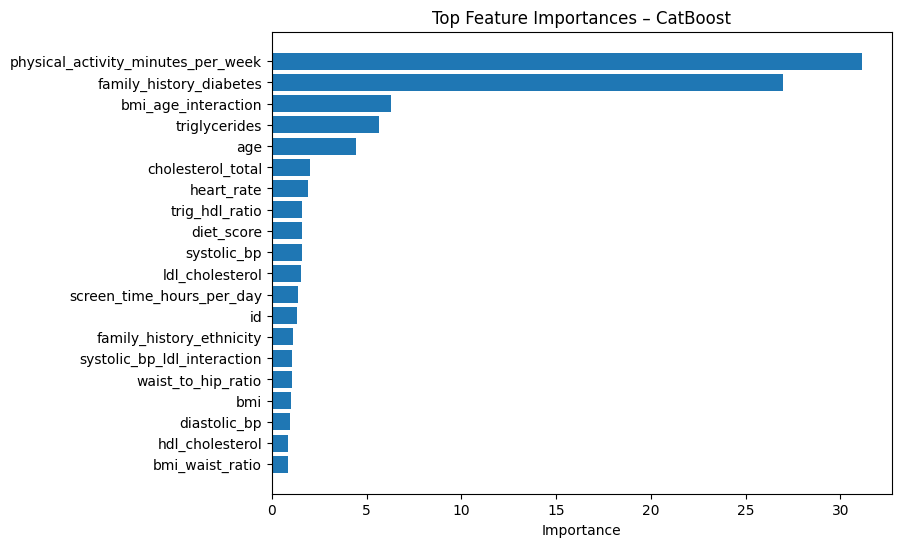

In [ ]:
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(
    fi_df['feature'].head(top_n)[::-1],
    fi_df['importance'].head(top_n)[::-1]
)
plt.title("Top Feature Importances – CatBoost")
plt.xlabel("Importance")
plt.show()

c:\Users\pasup\Downloads\playground-series-s5e12\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


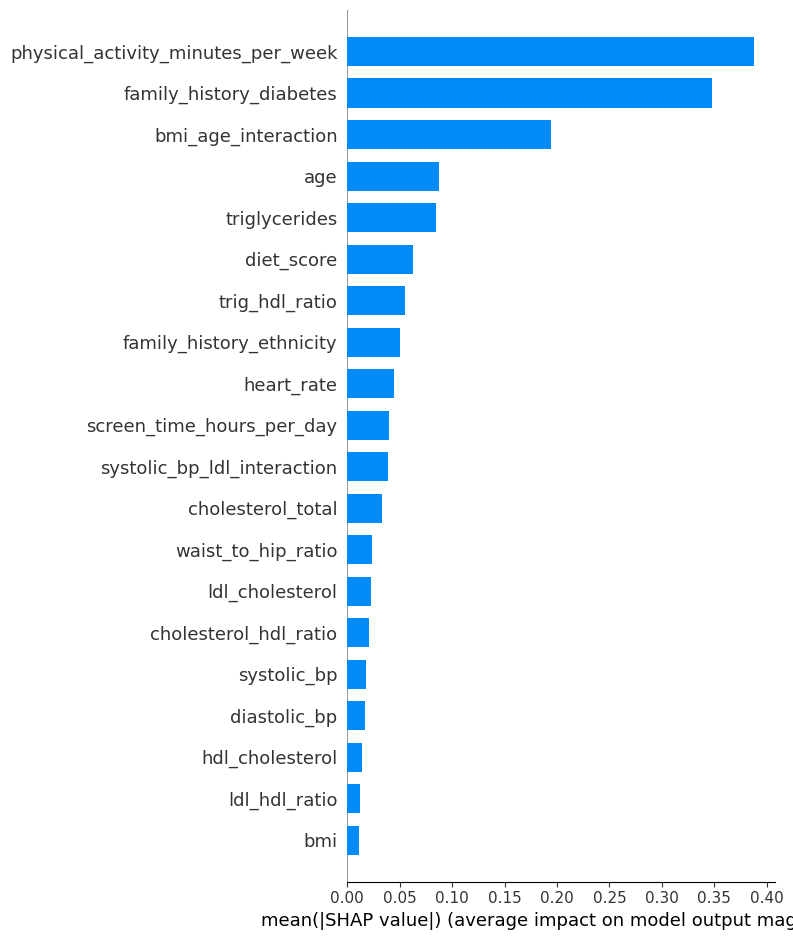

In [ ]:
# Shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid)

shap.summary_plot(shap_values, X_valid, plot_type="bar")

#### Train & Validation Data

In [ ]:
# Predictions and Probabilities

y_valid_pred = model.predict(X_valid) 
y_valid_proba = model.predict_proba(X_valid)[:, 1]

y_train_pred = model.predict(X_train) 
y_train_proba = model.predict_proba(X_train)[:, 1]

In [ ]:
# Accuracy values

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])

print("Train AUC:", round(train_auc, 4))
print("Valid AUC:", round(valid_auc, 4))

Train AUC: 0.7388
Valid AUC: 0.7252


In [ ]:
# classification report Train & Validation data
print( "Train", classification_report(y_train, y_train_pred))
print("\n")
print( "Validation", classification_report(y_valid, y_valid_pred))

Train               precision    recall  f1-score   support

         0.0       0.54      0.71      0.61    210954
         1.0       0.78      0.64      0.70    349046

    accuracy                           0.66    560000
   macro avg       0.66      0.67      0.66    560000
weighted avg       0.69      0.66      0.67    560000



Validation               precision    recall  f1-score   support

         0.0       0.53      0.70      0.60     52739
         1.0       0.77      0.63      0.69     87261

    accuracy                           0.65    140000
   macro avg       0.65      0.66      0.65    140000
weighted avg       0.68      0.65      0.66    140000



#### Confusion Matrix

In [ ]:
# CM of Valdation data
cm_val = confusion_matrix(y_valid, y_valid_pred)
cm_val

array([[36794, 15945],
       [32557, 54704]])

In [ ]:
# CM's O/p in simple language
cm_val_df = pd.DataFrame(
    cm_val,
    index=['Actual No Diabetes', 'Actual Diabetes'],
    columns=['Predicted No Diabetes', 'Predicted Diabetes']
)
cm_val_df

,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,36794,15945
Actual Diabetes,32557,54704


In [ ]:
# Confusion Matrix of Train Data
cm_train = confusion_matrix(y_train, y_train_pred)
cm_train

array([[149506,  61448],
       [127200, 221846]])

In [ ]:
# CM's O/p in simple language
cm_train_df = pd.DataFrame(
    cm_train,
    index=['Actual No Diabetes', 'Actual Diabetes'],
    columns=['Predicted No Diabetes', 'Predicted Diabetes']
)
cm_train_df

,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,149506,61448
Actual Diabetes,127200,221846


### Test Data

In [ ]:
test_df = feature_engineering(test_df)
X_test = test_df[X.columns]   # ensures column order matches training
test_pred = model.predict(X_test)
test_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(X_test, test_proba)
print("Validation AUC:", auc)

In [42]:
submission_cat = pd.DataFrame({
    'id': test_df['id'],              # adjust column name
    'diagnosed_diabetes': test_proba
})

submission_cat.to_csv("submission_cat.csv", index=False)

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_valid_pred)
cm

array([[36794, 15945],
       [32557, 54704]])

### Modelling - Catboost, Top Features


To be continued, 05/03/2026

In [ ]:
top_features = fi_df.head(10)['feature'].tolist()

X_train_reduced = X_train[top_features]
X_valid_reduced = X_valid[top_features]
X_test_reduced = X_test[top_features]